In [ ]:
# %uv pip install numpy quantities matplotlib new elephant viziphant nixio pyocclient tqdm

# Unitary Event Analysis (UAE) and SPADE: Discovering Spike Synchrony with Coincidence Detection

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day1-Spike-Train-Correlations/blob/main/03_synchrony_detection/03_synchrony_detection.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Setup

### Import Libraries

Import the modules required for this session.

In [ ]:
import numpy as np
import quantities as pq
from matplotlib import pyplot as plt
import neo
import neo.io
import elephant.unitary_event_analysis as ue
import elephant.statistics as stats
import elephant.spike_train_surrogates as surr
from elephant.spike_train_generation import StationaryPoissonProcess, NonStationaryPoissonProcess, compound_poisson_process
from elephant.spade import spade
from viziphant.unitary_event_analysis import plot_ue
from viziphant.patterns import plot_patterns

np.random.seed(42)
%matplotlib inline

### Utility Functions

Define the utility functions required for this session.

In [2]:
class utils:
    @staticmethod
    def generate_spike_trains_with_coinc(rate_b, rate_c, trial_duration, coinc_duration,
                                         num_trials, num_units=2, unit_ids_sync=None):
        """Simulate spike trains with injected coincidences in the centre of each trial."""
        if unit_ids_sync is None:
            unit_ids_sync = [[1, 2]]
        if not isinstance(unit_ids_sync[0], (list, tuple)):
            unit_ids_sync = [list(unit_ids_sync)]

        t_coinc_start = (trial_duration - coinc_duration) / 2.
        t_coinc_stop = t_coinc_start + coinc_duration

        sync_count = np.zeros(num_units, dtype=int)
        for subset in unit_ids_sync:
            for uid in subset:
                sync_count[uid - 1] += 1

        spike_trains = []
        for _ in range(num_trials):
            pre  = [StationaryPoissonProcess(rate_b, t_stop=t_coinc_start).generate_spiketrain()
                    for _ in range(num_units)]
            mid_rates = [max((rate_b - rate_c * sync_count[i]).rescale(pq.Hz).magnitude, 0) * pq.Hz
                         for i in range(num_units)]
            mid  = [StationaryPoissonProcess(mid_rates[i], t_start=t_coinc_start,
                                             t_stop=t_coinc_stop).generate_spiketrain()
                    for i in range(num_units)]
            post = [StationaryPoissonProcess(rate_b, t_start=t_coinc_stop,
                                             t_stop=trial_duration).generate_spiketrain()
                    for _ in range(num_units)]
            coinc = [StationaryPoissonProcess(rate_c, t_start=t_coinc_start,
                                              t_stop=t_coinc_stop).generate_spiketrain()
                     for _ in unit_ids_sync]

            trial = []
            for i in range(num_units):
                parts = [pre[i].times.rescale(pq.ms).magnitude,
                         mid[i].times.rescale(pq.ms).magnitude,
                         post[i].times.rescale(pq.ms).magnitude]
                for j, subset in enumerate(unit_ids_sync):
                    if (i + 1) in subset:
                        parts.append(coinc[j].times.rescale(pq.ms).magnitude)
                times = np.sort(np.concatenate(parts)) * pq.ms
                trial.append(neo.SpikeTrain(times, t_start=0. * pq.ms, t_stop=trial_duration))
            spike_trains.append(trial)
        return spike_trains

    @staticmethod
    def compute_complexity_distribution(spike_trains, bin_size):
        """Compute the normalised complexity distribution of a list of spike trains."""
        n = len(spike_trains)
        complexity = stats.Complexity(spike_trains, bin_size=bin_size, binary=True)
        dist = complexity.pdf().flatten().magnitude
        return np.concatenate([dist, np.zeros(n - len(dist))])
        
    @staticmethod
    def generate_spike_trains_with_osc_rates(
            num_trials, num_units, trial_duration,
            rate_offset, rate_amplitude, rate_frequency,
            coinc_offset=0 * pq.Hz, coinc_amplitude=0 * pq.Hz, coinc_frequency=0 * pq.Hz):
        """Simulate spike trains with an oscillatory background rate and optional coincidences."""
        dt = 1 * pq.ms
        n = int(trial_duration.rescale(pq.ms).magnitude)
        t_s = np.arange(n) * dt.rescale(pq.s).magnitude
        pi2 = 2 * np.pi
        bg = np.maximum(
            rate_offset.rescale(pq.Hz).magnitude
            + rate_amplitude.rescale(pq.Hz).magnitude
            * np.sin(pi2 * rate_frequency.rescale(pq.Hz).magnitude * t_s), 0) * pq.Hz
        coinc = np.maximum(
            coinc_offset.rescale(pq.Hz).magnitude
            + coinc_amplitude.rescale(pq.Hz).magnitude
            * np.sin(pi2 * coinc_frequency.rescale(pq.Hz).magnitude * t_s), 0) * pq.Hz
        spike_trains = []
        for _ in range(num_trials):
            bg_sig = neo.AnalogSignal(bg, t_start=0 * pq.ms, sampling_period=dt)
            coinc_sig = neo.AnalogSignal(coinc, t_start=0 * pq.ms, sampling_period=dt)
            coinc_st = NonStationaryPoissonProcess(coinc_sig).generate_spiketrain()
            trial = []
            for _ in range(num_units):
                bg_st = NonStationaryPoissonProcess(bg_sig).generate_spiketrain()
                times = np.sort(np.concatenate([
                    bg_st.times.rescale(pq.ms).magnitude,
                    coinc_st.times.rescale(pq.ms).magnitude])) * pq.ms
                trial.append(neo.SpikeTrain(times, t_start=0. * pq.ms, t_stop=trial_duration))
            spike_trains.append(trial)
        return spike_trains

    @staticmethod
    def load_spike_trains(filename):
        """Load all trials for one neuron from a .nix file."""
        with neo.io.NixIO(filename, "ro") as io:
            return [seg.spiketrains[0] for seg in io.read_block().segments]


### Download Data

In [ ]:
import os
import owncloud
from tqdm import tqdm

oc = owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/4KWyXRRFMZNSXcb', folder_password='ibots')

os.makedirs('data', exist_ok=True)
for f in tqdm(oc.list('/'), desc='Downloading Files to data/'):
    if not os.path.exists(f'data{f.path}'):
        oc.get_file(f.path, f'data{f.path}')

## Unitary Event Analysis (UEA)

Unitary Event Analysis (UEA) detects time intervals in which two or more neurons fire synchronously more often than expected by chance given their individual firing rates. The method slides a window across trials and computes a surprise measure: positive values indicate excess synchrony, negative values indicate a deficit.

### Simulating Data with Embedded Synchrony

Before applying UEA to real data, we use simulations with a known coincidence structure to understand the method and its parameters.

| Code | Description |
| --- | --- |
| `trials = utils.generate_spike_trains_with_coinc(rate_b, rate_c, trial_duration, coinc_duration, num_trials)` | Simulate `num_trials` trials; each trial is a list of 2 spike trains with coincidences at rate `rate_c` for `coinc_duration` in the middle |
| `ue_result = ue.jointJ_window_analysis(trials)` | Apply UEA to the list of trials with default parameters |
| `ue_result = ue.jointJ_window_analysis(trials, bin_size=1*pq.ms, win_size=100*pq.ms)` | Apply UEA with specific `bin_size` and `win_size` |
| `plot_ue(trials, ue_result, significance_level=0.05)` | Plot the UEA result |

> **Units and spike train objects**: Parameters use the `quantities` library — write `30 * pq.Hz`, `1000 * pq.ms`, etc. and Elephant handles the units automatically. Spike trains are `neo.SpikeTrain` objects; you can pass them directly to all Elephant functions without unpacking them.




#### **Exercises**

**Example**: Simulate 50 trials with `rate_b=30*pq.Hz`, `rate_c=2*pq.Hz`, and a 100 ms coincidence window. Apply UEA and plot the result.

FigureUE(axes_spike_events=<Axes: title={'center': 'Spike Events'}, ylabel='Trial'>, axes_spike_rates=<Axes: title={'center': 'Spike Rates'}, ylabel='Hz'>, axes_coincident_events=<Axes: title={'center': 'Coincident Events'}, ylabel='Trial'>, axes_coincidence_rates=<Axes: title={'center': 'Coincidence Rates'}, ylabel='Hz'>, axes_significance=<Axes: title={'center': 'Statistical Significance'}>, axes_unitary_events=<Axes: title={'center': 'Unitary Events'}, xlabel='Time (ms)', ylabel='Trial'>)

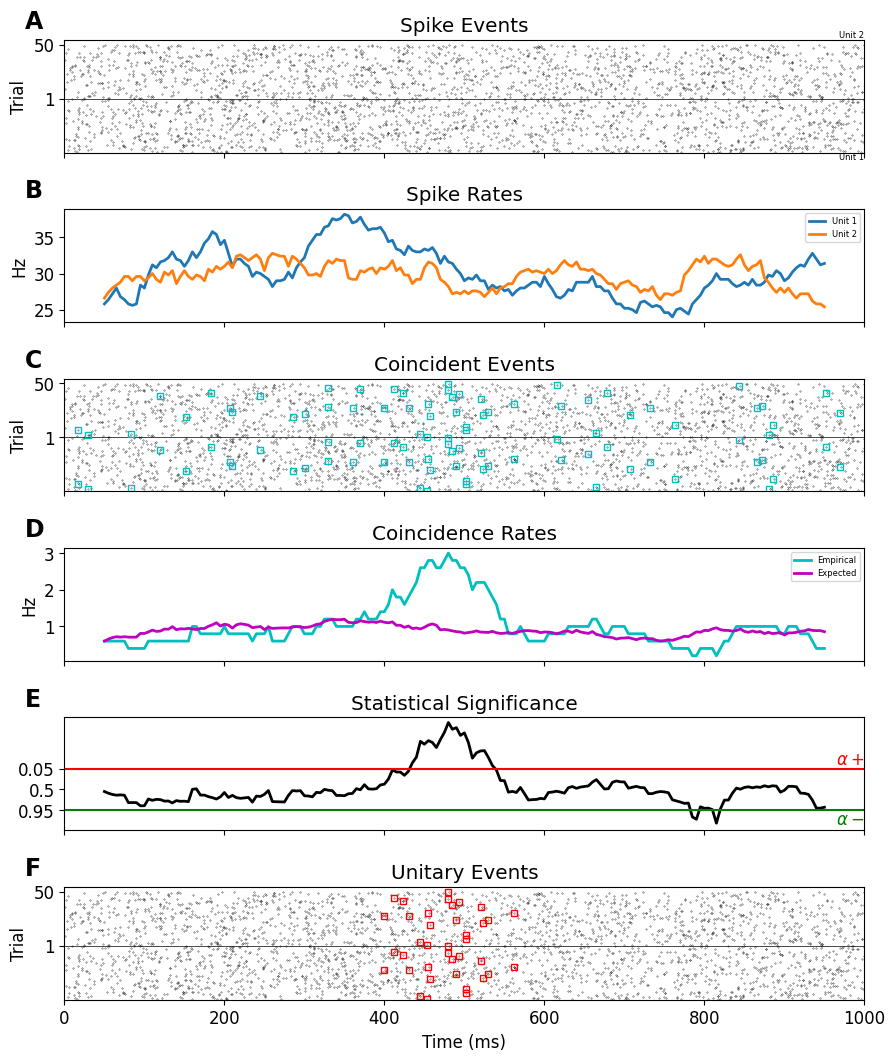

In [3]:
num_trials = 50
trial_duration = 1000 * pq.ms
rate_b = 30 * pq.Hz
rate_c = 2 * pq.Hz
coinc_duration = 100 * pq.ms

trials = utils.generate_spike_trains_with_coinc(
    rate_b, rate_c, trial_duration, coinc_duration, num_trials
)
ue_result = ue.jointJ_window_analysis(
    trials, bin_size=1 * pq.ms, win_size=100 * pq.ms
)
plot_ue(trials, ue_result, significance_level=0.05, unit_real_ids=[1, 2])

**Exercise**: Increase `num_trials` to `200`. Rerun `generate_spike_trains_with_coinc` and `jointJ_window_analysis`. Does the surprise in the coincidence window increase? Does the number of significantly marked events change?

**Exercise**: Using the 50 trial simulation from the Example (reset `num_trials=50` and rerun `generate_spike_trains_with_coinc`), apply `jointJ_window_analysis` with `win_size=900*pq.ms` (close to the full trial duration). Plot the result. Do you observe significant events? Why might an overly large analysis window suppress detection?

**Exercise**: Print `ue.hash_from_pattern([1, 1])` and `ue.hash_from_pattern([1, 0])`. What does each hash value encode? How would you specify that only neuron 2 should fire (pattern `[0, 1]`)?

**Exercise**: Simulate 50 trials with `rate_b=30*pq.Hz`, `rate_c=2*pq.Hz`, and `coinc_duration=200*pq.ms` (longer coincidence window). Apply UEA with `win_size=100*pq.ms`. Does a longer coincidence window produce more significant events? Why might the surprise value change?

**Exercise**: Rerun `jointJ_window_analysis` with `win_size=25*pq.ms` and plot. How does the temporal precision of the detected synchrony change compared to `win_size=100*pq.ms`?

**Exercise**: Simulate 50 trials with `rate_b=80*pq.Hz` and `rate_c=2*pq.Hz`. Apply UEA with `win_size=100*pq.ms`. Do you still observe significant events? Why does a higher background rate make coincidences harder to detect?

**Exercise**: Simulate 50 trials with `rate_b=30*pq.Hz` and `rate_c=0.5*pq.Hz` (fewer coincidences). Apply UEA with `win_size=100*pq.ms`. Does the number of significantly marked events decrease compared to `rate_c=2*pq.Hz`? What does this tell you about the sensitivity of UEA to the coincidence rate?

**Explore**: For the 50 trial simulation with `rate_b=30*pq.Hz` and `rate_c=2*pq.Hz`, print `ue_result['n_emp']`. This array contains the number of observed coincidences in each window. Also print `ue_result['n_exp']` for the expected count. In which windows are the two most different?

In [11]:
trials = utils.generate_spike_trains_with_coinc(
    rate_b=30 * pq.Hz, rate_c=2 * pq.Hz,
    trial_duration=1000 * pq.ms, coinc_duration=100 * pq.ms,
    num_trials=50
)
ue_result = ue.jointJ_window_analysis(
    trials, bin_size=1 * pq.ms, win_size=100 * pq.ms
)
print("n_emp:", ue_result['n_emp'])
print("n_exp:", ue_result['n_exp'])

n_emp: [[ 9.]
 [ 8.]
 [ 9.]
 [ 9.]
 [ 9.]
 [ 9.]
 [ 9.]
 [ 9.]
 [ 9.]
 [ 9.]
 [10.]
 [10.]
 [10.]
 [10.]
 [ 8.]
 [ 8.]
 [ 9.]
 [ 7.]
 [ 6.]
 [ 5.]
 [ 5.]
 [ 5.]
 [ 4.]
 [ 4.]
 [ 5.]
 [ 5.]
 [ 5.]
 [ 5.]
 [ 5.]
 [ 5.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 5.]
 [ 4.]
 [ 4.]
 [ 4.]
 [ 4.]
 [ 4.]
 [ 5.]
 [ 5.]
 [ 5.]
 [ 4.]
 [ 4.]
 [ 4.]
 [ 4.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 9.]
 [ 9.]
 [ 9.]
 [11.]
 [12.]
 [13.]
 [13.]
 [14.]
 [14.]
 [14.]
 [15.]
 [17.]
 [17.]
 [18.]
 [17.]
 [16.]
 [15.]
 [15.]
 [14.]
 [14.]
 [11.]
 [10.]
 [11.]
 [ 9.]
 [ 8.]
 [ 7.]
 [ 7.]
 [ 7.]
 [ 7.]
 [ 7.]
 [ 6.]
 [ 4.]
 [ 4.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 4.]
 [ 4.]
 [ 4.]
 [ 3.]
 [ 3.]
 [ 4.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 3.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 1.]
 [ 1.]
 [ 2.]
 [ 3.]
 [ 3.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]

### Pairwise vs. Higher Order Synchrony

UEA can search for synchrony in subsets of neurons. The `pattern_hash` argument specifies which neurons participate. A pattern `[1, 1, 1]` means all three neurons must fire together; `[1, 1, 0]` means only neurons 1 and 2.

| Code | Description |
| --- | --- |
| `trials = utils.generate_spike_trains_with_coinc(..., num_units=3, unit_ids_sync=[[1,2,3]])` | Simulate 3 neurons with triple coincidences |
| `ph = ue.hash_from_pattern([1, 1, 1])` | Hash for the triplet pattern |
| `ue_result = ue.jointJ_window_analysis(trials, pattern_hash=[ph])` | Apply UEA searching for the specified pattern |

---

#### **Exercises**

**Example**: Simulate 3 neurons with coincidences in all three (`unit_ids_sync=[[1,2,3]]`). Apply UEA with the triplet pattern.

FigureUE(axes_spike_events=<Axes: title={'center': 'Spike Events'}, ylabel='Trial'>, axes_spike_rates=<Axes: title={'center': 'Spike Rates'}, ylabel='Hz'>, axes_coincident_events=<Axes: title={'center': 'Coincident Events'}, ylabel='Trial'>, axes_coincidence_rates=<Axes: title={'center': 'Coincidence Rates'}, ylabel='Hz'>, axes_significance=<Axes: title={'center': 'Statistical Significance'}>, axes_unitary_events=<Axes: title={'center': 'Unitary Events'}, xlabel='Time (ms)', ylabel='Trial'>)

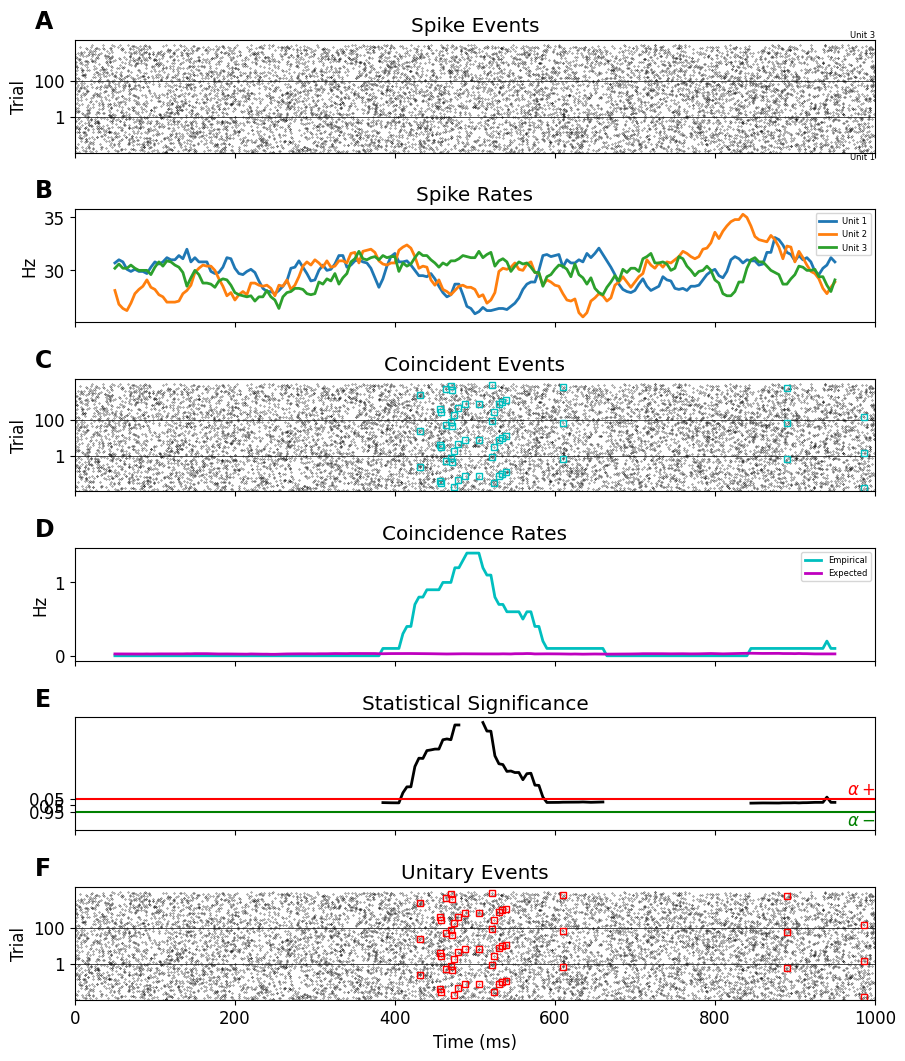

In [12]:
trials3 = utils.generate_spike_trains_with_coinc(
    rate_b=30 * pq.Hz, rate_c=2 * pq.Hz,
    trial_duration=1000 * pq.ms, coinc_duration=100 * pq.ms,
    num_trials=100, num_units=3, unit_ids_sync=[[1, 2, 3]]
)
ph_triplet = ue.hash_from_pattern([1, 1, 1])
ue_result3 = ue.jointJ_window_analysis(
    trials3, bin_size=1 * pq.ms, win_size=100 * pq.ms, pattern_hash=[ph_triplet]
)
plot_ue(trials3, ue_result3, significance_level=0.05, unit_real_ids=[1, 2, 3])

**Exercise**: Change `unit_ids_sync=[[1,2],[2,3]]` to inject only pairwise coincidences between neurons (1,2) and (2,3). Rerun `generate_spike_trains_with_coinc` with `num_trials=100, num_units=3`. Apply `jointJ_window_analysis` with `ph_triplet` and plot. Is the triplet pattern significant?

**Exercise**: Rerun `jointJ_window_analysis` on the same pairwise data with `pattern_hash=[ue.hash_from_pattern([1,1,0])]` (neurons 1 and 2 only). Is this pairwise pattern significant? What does this tell you about the importance of specifying the correct pattern order?

### Non-Stationary Firing Rates

Real neuronal firing rates often oscillate in time. When both neurons share a common rate modulation, the expected coincidence count rises and falls with the rate — and UEA may report false excess synchrony even without genuine coordination. Here we examine this effect and see how the `"analytic_TrialAverage"` method handles it.

`utils.generate_spike_trains_with_osc_rates` generates spike trains with a sinusoidal background rate and an optional sinusoidal coincidence process.

| Code | Description |
| --- | --- |
| `utils.generate_spike_trains_with_osc_rates(num_trials, 2, trial_duration, rate_offset, rate_amplitude, rate_frequency)` | Oscillatory background, no injected coincidences |
| `utils.generate_spike_trains_with_osc_rates(..., coinc_amplitude=2*pq.Hz, coinc_frequency=2*pq.Hz)` | Oscillatory coincidences added on top |

---

#### **Exercises**

**Example**: Simulate 100 trials with a 5 Hz oscillatory background rate and no injected coincidences. Apply UEA with `win_size=100*pq.ms`. Does the surprise show false positives tied to the rate modulation?

FigureUE(axes_spike_events=<Axes: title={'center': 'Spike Events'}, ylabel='Trial'>, axes_spike_rates=<Axes: title={'center': 'Spike Rates'}, ylabel='Hz'>, axes_coincident_events=<Axes: title={'center': 'Coincident Events'}, ylabel='Trial'>, axes_coincidence_rates=<Axes: title={'center': 'Coincidence Rates'}, ylabel='Hz'>, axes_significance=<Axes: title={'center': 'Statistical Significance'}>, axes_unitary_events=<Axes: title={'center': 'Unitary Events'}, xlabel='Time (ms)', ylabel='Trial'>)

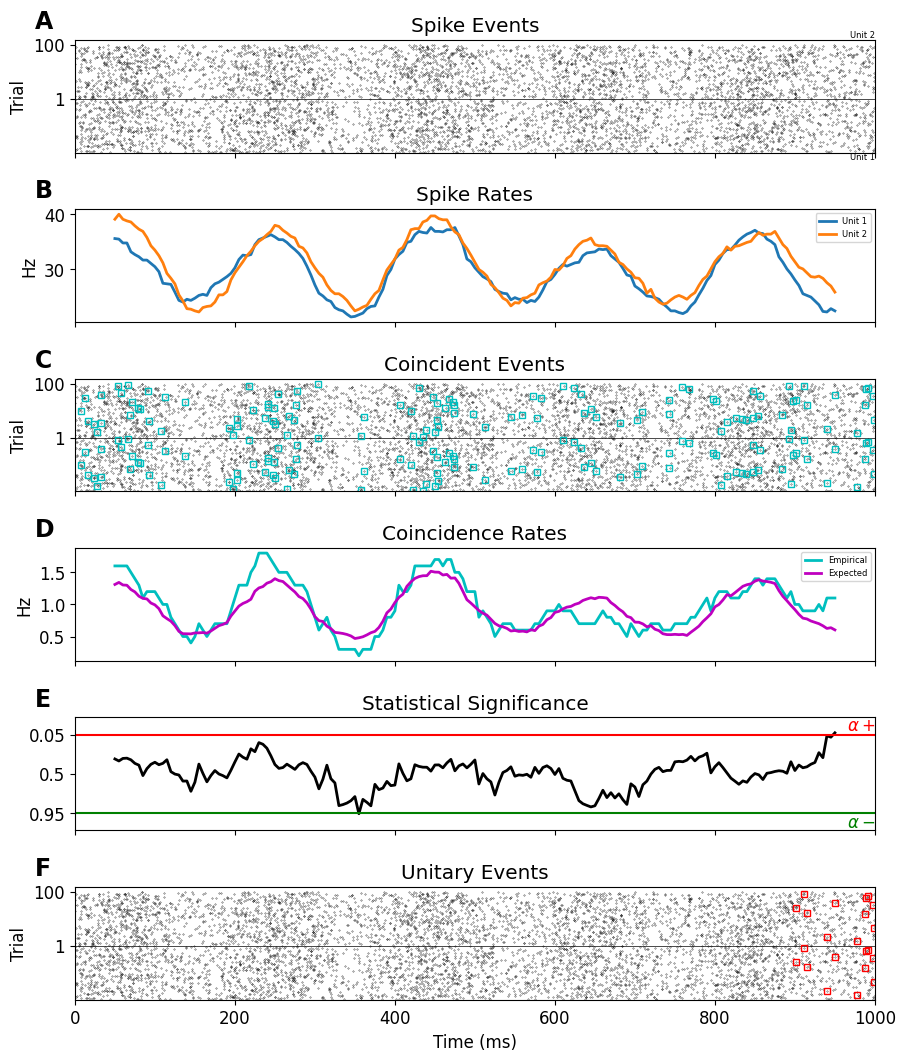

In [15]:
num_trials = 100
trial_duration = 1000 * pq.ms

trials_osc = utils.generate_spike_trains_with_osc_rates(
    num_trials=num_trials, num_units=2, trial_duration=trial_duration,
    rate_offset=30 * pq.Hz, rate_amplitude=10 * pq.Hz, rate_frequency=5 * pq.Hz
)
ue_result_osc = ue.jointJ_window_analysis(
    trials_osc, bin_size=1 * pq.ms, win_size=100 * pq.ms
)
plot_ue(trials_osc, ue_result_osc, significance_level=0.05, unit_real_ids=[1, 2])

**Exercise**: Add an oscillatory coincidence process to the same background: `coinc_offset=0*pq.Hz`, `coinc_amplitude=2*pq.Hz`, `coinc_frequency=2*pq.Hz`. Apply UEA with `win_size=100*pq.ms`. Does UEA correctly detect the excess synchrony in windows where the coincidence rate is highest, despite the oscillating background?

**Exercise**: Return to the oscillatory background without coincidences (`trials_osc`). Rerun `jointJ_window_analysis` with `method="analytic_TrialAverage"`. Does this method reduce the false positives? What does trial averaging the expected count do differently from the default method?

### UEA on Real Data

We now apply UEA to spike trains recorded from motor cortex of a macaque monkey during a delayed pointing task (Riehle et al., 1997). The delay duration varied from trial to trial (600–1500 ms). Thirty-six trials with the longest delay are pooled here. The monkey could anticipate the reaction signal (RS) at three earlier expected moments (ES1, ES2, ES3) before it actually occurred.

Time stamps of events relative to the preparatory signal (PS): PS = 300 ms, ES1 = 900 ms, ES2 = 1200 ms, ES3 = 1500 ms, RS = 1800 ms.

| Code | Description |
| --- | --- |
| `spiketrains = [[st1, st2] for st1, st2 in zip(spike_trains1, spike_trains2)]` | Combine two neurons into the trial-list format expected by UEA |
| `ue.jointJ_window_analysis(spiketrains, method="analytic_TrialAverage")` | Apply UEA using the analytic trial-average method |
| `plot_ue(spiketrains, ue_result, events={"PS": [300*pq.ms], ...})` | Plot UEA result with labelled event times |

---

#### **Exercises**

**Example**: Load `Data14.npy` and `Data15.npy` and apply UEA with the behavioural event markers.

/home/denker/Projects/teaching/anda-course/Gruen - Spike Train Correlations/02_Unitary Events and Higher-Order Correlations/.venv/lib/python3.14/site-packages/elephant/conversion.py:1158: UserWarning: Binning discarded 1 last spike(s) of the input spiketrain
  warnings.warn("Binning discarded {} last spike(s) of the "


FigureUE(axes_spike_events=<Axes: title={'center': 'Spike Events'}, ylabel='Trial'>, axes_spike_rates=<Axes: title={'center': 'Spike Rates'}, ylabel='Hz'>, axes_coincident_events=<Axes: title={'center': 'Coincident Events'}, ylabel='Trial'>, axes_coincidence_rates=<Axes: title={'center': 'Coincidence Rates'}, ylabel='Hz'>, axes_significance=<Axes: title={'center': 'Statistical Significance'}>, axes_unitary_events=<Axes: title={'center': 'Unitary Events'}, xlabel='Time (ms)', ylabel='Trial'>)

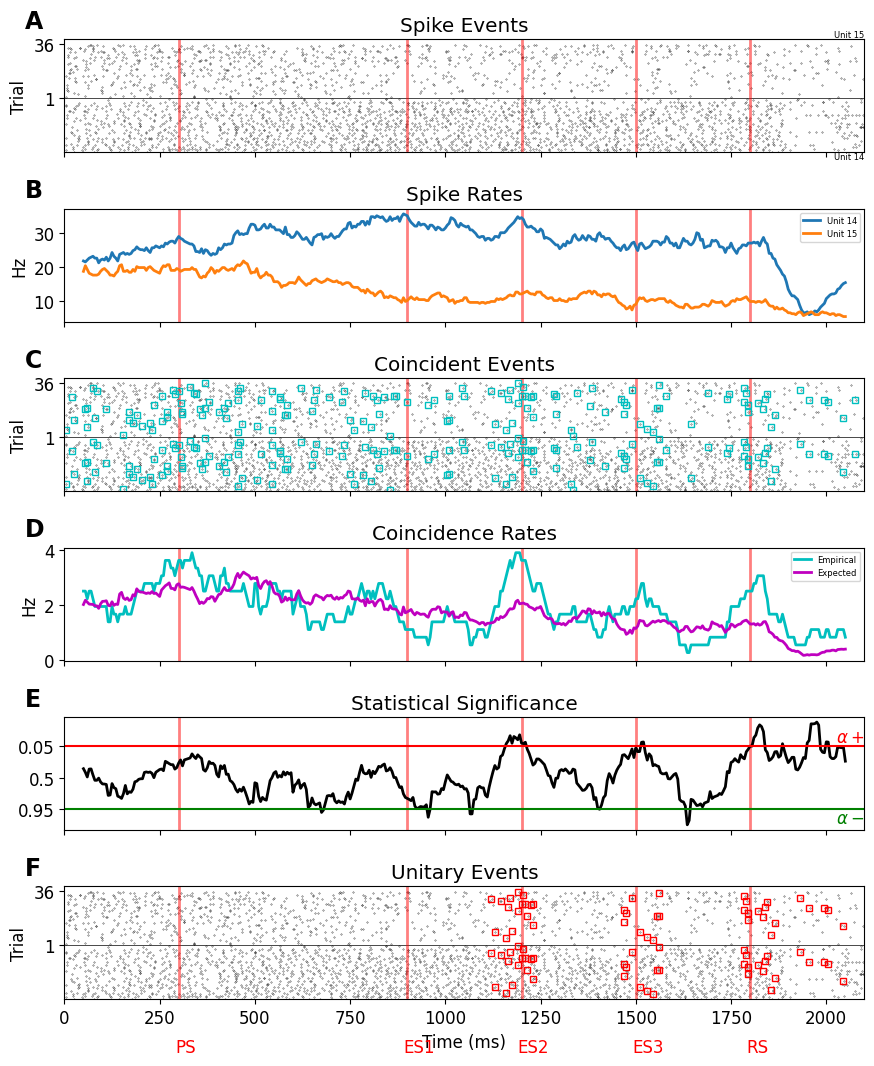

In [18]:
spike_trains14 = utils.load_spike_trains("data/Data14.nix")
spike_trains15 = utils.load_spike_trains("data/Data15.nix")
spiketrains_real = [[st1, st2] for st1, st2 in zip(spike_trains14, spike_trains15)]

ue_result_real = ue.jointJ_window_analysis(
    spiketrains_real, bin_size=5 * pq.ms, win_size=100 * pq.ms,
    method="analytic_TrialAverage"
)
events = {"PS": [300 * pq.ms], "ES1": [900 * pq.ms],
          "ES2": [1200 * pq.ms], "ES3": [1500 * pq.ms], "RS": [1800 * pq.ms]}
plot_ue(spiketrains_real, ue_result_real, significance_level=0.05,
        unit_real_ids=(14, 15), events=events)

**Exercise**: Change `significance_level` to `0.01` in `plot_ue`. How many significant events remain? Around which behavioural events do they cluster?

**Exercise**: Print `list(ue_result_real.keys())` to see the available output fields. Then print `ue_result_real["rate_avg"]`. What do the two values represent, given that the recording contains two neurons?

**Exercise**: Print `ue_result_real['Js'].shape`. What do the two dimensions of this array represent? Then print `np.max(ue_result_real['Js'])` to find the peak surprise value and `ue_result_real['input_parameters']` to inspect the analysis settings.

**Exercise**: Rerun `jointJ_window_analysis` on the real data with `win_size=50*pq.ms` and plot. How does the temporal spread of the significant events change compared to the 100 ms window?

**Exercise**: Rerun with `win_size=250*pq.ms` and plot. How do the surprise values in the coincidence windows compare to the `win_size=50*pq.ms` case?

**Exercise**: Based on the three window sizes you have tested (50, 100, 250 ms), which window size gives the highest surprise values in the expected coincidence windows? Print `np.max(ue_result_real['Js'])` for each result and compare. What does this suggest about the temporal precision of the synchrony in this dataset?

## Population Spiking and the Complexity Distribution

The **complexity distribution** counts how often exactly $k$ neurons fire synchronously in a time bin. For independent neurons, this distribution is governed by the individual firing rates. Correlations produce excess synchrony at high complexities. By comparing the complexity distribution of the data to an independent surrogate, we can detect higher order correlations without specifying which neurons are involved.

The **Compound Poisson Process (CPP)** is a model that generates correlated spike trains: a Poisson process fires an event that is copied to $k$ neurons simultaneously (with probability given by the amplitude distribution). This makes it ideal for simulating population synchrony with controlled structure.

| Code | Description |
| --- | --- |
| `sts = compound_poisson_process(rate, amplitude_distribution, t_stop)` | Generate spike trains from a CPP; length of `amplitude_distribution` minus 1 is the number of neurons |
| `complexity = stats.Complexity(sts, bin_size=1*pq.ms, binary=True)` | Compute the complexity object |
| `complexity.pdf().flatten().magnitude` | Get the normalised complexity distribution |
| `complexity.time_histogram` | Get the population spike count over time |

---

#### **Exercises**

**Example**: Generate 100 spike trains from a CPP with `assembly_size=20` and a 5% probability of a synchronous event. Plot the raster, population histogram, and both the amplitude and complexity distributions.

/home/denker/Projects/teaching/anda-course/Gruen - Spike Train Correlations/02_Unitary Events and Higher-Order Correlations/.venv/lib/python3.14/site-packages/elephant/statistics.py:1647: UserWarning: No sampling rate specified. Note that using the complexity epoch to get precise spike times can lead to rounding errors.
  warnings.warn('No sampling rate specified. '


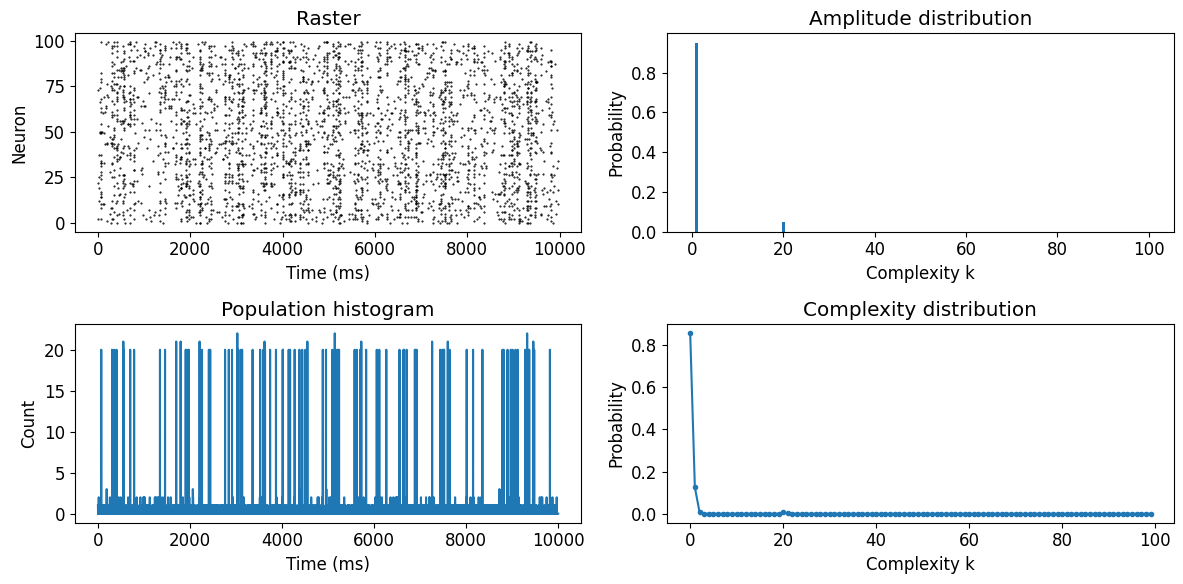

In [25]:
num_units = 100
rate = 3 * pq.Hz
t_stop = 10 * pq.s
assembly_size = 20
p_coinc = 0.05
jitter = 0 * pq.ms

amp_dist = np.zeros(num_units + 1)
amp_dist[1] = 1. - p_coinc
amp_dist[assembly_size] = p_coinc

sts = compound_poisson_process(rate=rate, amplitude_distribution=amp_dist,
                               t_stop=t_stop, shift=jitter)

complexity = stats.Complexity(sts, bin_size=1 * pq.ms, binary=True)
dist_cpp = utils.compute_complexity_distribution(sts, 1 * pq.ms)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, st in enumerate(sts):
    axes[0, 0].plot(st.rescale("ms").magnitude, [i] * len(st), ".k", ms=1)
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Neuron")
axes[0, 0].set_title("Raster")

pophist = complexity.time_histogram
axes[1, 0].plot(pophist.times.rescale("ms"), pophist[:, 0])
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Population histogram")

axes[0, 1].bar(np.arange(len(amp_dist)), amp_dist)
axes[0, 1].set_xlabel("Complexity k")
axes[0, 1].set_ylabel("Probability")
axes[0, 1].set_title("Amplitude distribution")

axes[1, 1].plot(np.arange(num_units), dist_cpp, ".-")
axes[1, 1].set_xlabel("Complexity k")
axes[1, 1].set_ylabel("Probability")
axes[1, 1].set_title("Complexity distribution")
plt.tight_layout()

**Exercise**: Change `assembly_size` to `5` and rerun. Where does the peak of the complexity distribution shift? What does this tell you about the order of synchrony in the data?

**Exercise**: Set `assembly_size=2` (pairwise synchrony) and `p_coinc=0.10`. Rerun the CPP generation and the surrogate comparison. Where does the excess synchrony peak in the difference distribution? Is it harder or easier to detect than `assembly_size=20`?

**Exercise**: Reset `assembly_size=20`, `p_coinc=0.05`, `jitter=0*pq.ms`. Change `rate=10*pq.Hz` (higher firing rate) and regenerate the CPP. Compute the surrogate and difference distributions. Does increasing the firing rate make the assembly synchrony easier or harder to detect?

**Example**: Generate independent surrogate spike trains by randomising spike times and compare the complexity distributions of the CPP and the surrogates.

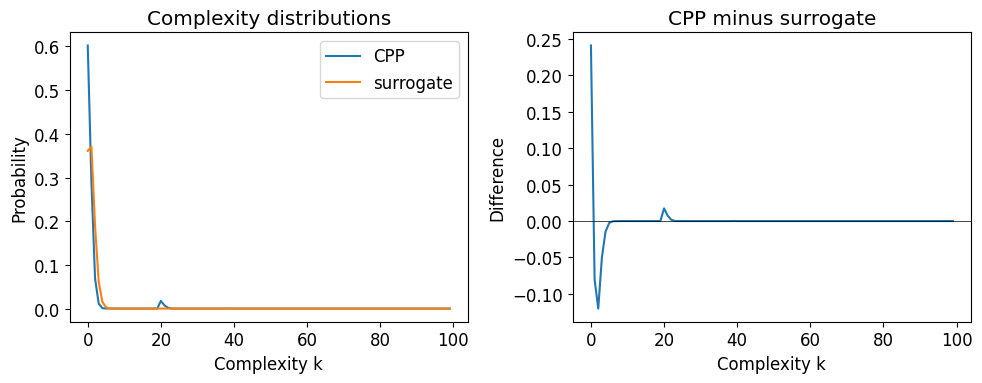

In [29]:
surr_sts = [surr.surrogates(st, n_surrogates=1, method="randomise_spikes")[0] for st in sts]
dist_surr = utils.compute_complexity_distribution(surr_sts, 1 * pq.ms)
dist_diff = dist_cpp - dist_surr

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(np.arange(num_units), dist_cpp, label="CPP")
axes[0].plot(np.arange(num_units), dist_surr, label="surrogate")
axes[0].set_xlabel("Complexity k")
axes[0].set_ylabel("Probability")
axes[0].set_title("Complexity distributions")
axes[0].legend()

axes[1].plot(np.arange(num_units), dist_diff)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("Complexity k")
axes[1].set_ylabel("Difference")
axes[1].set_title("CPP minus surrogate")
plt.tight_layout()

**Exercise**: Reset `assembly_size=20` and change `p_coinc` to `0.20`. Rerun the CPP generation and the surrogate comparison. Is the excess synchrony more clearly visible in the difference plot?

**Exercise**: Set `p_coinc=0.05`, `assembly_size=20`, and `jitter=5*pq.ms`. Regenerate the CPP with `compound_poisson_process` and compute a surrogate with `surr.surrogates`. Recompute `dist_cpp`, `dist_surr`, and `dist_diff = dist_cpp - dist_surr` using `bin_size=1*pq.ms`. Plot `dist_diff`. Is the excess synchrony at complexity `k=assembly_size` still visible?

**Exercise**: Recompute `dist_cpp`, `dist_surr`, and `dist_diff` using `bin_size=10*pq.ms` in both calls to `utils.compute_complexity_distribution`. Is the excess synchrony now detectable? What does this tell you about the relationship between bin size and the temporal precision of synchrony detection?

**Exercise**: Reset `p_coinc=0.05`, `assembly_size=20`, `jitter=0*pq.ms`. Compute the complexity difference distribution with `bin_size=1*pq.ms` and then with `bin_size=20*pq.ms`. At what bin size does the excess synchrony disappear? What does this tell you about the temporal width of the coincidences?

## SPADE: Detecting Spike Patterns

SPADE (Spike PAttern Detection and Evaluation) finds recurring synchronous patterns in massively parallel spike trains. It mines the data for frequently co-occurring spikes (frequent itemset mining) and then tests their significance using surrogate data. Each detected pattern has a **signature** `(n_neurons, n_occurrences)`. SPADE can handle hundreds of neurons and find patterns that occur across any subset of them.

| Code | Description |
| --- | --- |
| `results = spade(sts, binsize, winlen)` | Run SPADE; `winlen` is the pattern window length in bins |
| `results = spade(sts, binsize, winlen, n_surr=100)` | Run SPADE with `100` surrogates for significance testing |
| `results = spade(sts, binsize, winlen, min_occ=3, min_neu=3)` | Only report patterns with ≥3 occurrences and ≥3 neurons |
| `results = spade(sts, binsize, winlen, n_surr=100, psr_param=[0, 1, 0])` | Run SPADE with pattern set reduction; removes patterns that are subsets of a larger significant pattern |
| `patterns = results["patterns"]` | List of detected patterns |
| `[p["signature"] for p in patterns]` | Get the `(n_neurons, n_occurrences)` signature of every pattern |
| `np.stack(sigs)` | Stack a list of signatures into a `(n_patterns, 2)` array |
| `plot_patterns(sts, patterns[0])` | Plot spike trains and highlight the first pattern |
| `[p for p in patterns if p["pvalue"] < 0.05]` | Filter significant patterns by p-value |

---

#### **Exercises**

**Example**: Generate a CPP with an assembly of 10 neurons embedded in 90 independent neurons. Apply SPADE and print the first detected pattern.

In [34]:
assembly_size = 10
p_coinc = 0.05
amp_dist_sip = np.zeros(assembly_size + 1)
amp_dist_sip[1] = 1. - p_coinc
amp_dist_sip[assembly_size] = p_coinc

sts_spade = compound_poisson_process(rate=3 * pq.Hz, amplitude_distribution=amp_dist_sip,
                                     t_stop=15 * pq.s)
for _ in range(90):
    sts_spade.append(StationaryPoissonProcess(rate=3 * pq.Hz, t_stop=15 * pq.s).generate_spiketrain())

print(f"Total neurons: {len(sts_spade)}")
results = spade(sts_spade, binsize=5 * pq.ms, winlen=1)
patterns = results["patterns"]
print(f"Patterns detected: {len(patterns)}")
patterns[0]

Total neurons: 100
Time for data mining: 0.13208508491516113
Patterns detected: 744


{'itemset': (np.int64(41), np.int64(78)),
 'windows_ids': (np.int64(2800), np.int64(2937)),
 'neurons': [np.int64(41), np.int64(78)],
 'lags': array([0.]) * ms,
 'times': array([14000., 14685.]) * ms,
 'signature': (2, 2),
 'pvalue': -1}

**Exercise**: Get the `"signature"` field from each pattern `p` in `patterns`. Collect them in a list called `sigs` and print the first five entries. What do the two numbers in each signature represent?

**Exercise**: Stack the list with `np.stack(sigs)` to form a 2D array `sig`. Print its shape. Which column gives the number of neurons in the pattern and which gives the number of occurrences?

**Exercise**: Use `np.argmax(sig[:, 0])` to find the index of the pattern with the most neurons and `np.argmax(sig[:, 1])` for the most frequently occurring pattern. Print both patterns.

**Exercise**: Rerun `spade()` with `min_occ=3` and `min_neu=3` to discard rare or small patterns. How many patterns remain? Print the signature of the most frequent remaining pattern.

**Exercise**: Run `spade()` with `n_surr=100`. Assign the result to `results_sig`. Print `results_sig["pvalue_spectrum"]`.

**Exercise**: From `results_sig["patterns"]`, keep only patterns where `p["pvalue"] < 0.05`. Store them in `sig_patterns` and print how many were found.

**Exercise**: For each significant pattern in `sig_patterns`, print `p['neurons']` to see which neuron IDs participate. Do the detected neurons correspond to the assembly you injected? Print the expected assembly neuron IDs by checking which spike trains in `sts_spade` came from the CPP: `list(range(assembly_size))`.

**Exercise**: Plot the significant patterns using `plot_patterns(sts_spade, sig_patterns)`.

**Exercise**: Rerun `spade()` with `n_surr=100` and `psr_param=[0, 1, 0]` (pattern set reduction). How many significant patterns remain after removing patterns that are subsets of a larger detected pattern?